In [ ]:
# ================================================================
#  RICCATI–STABILIZED LIE-GROUP OPTIMIZER DEMO  (SU(3), JAX)
#  Minimal, single-file codebase. Suitable for A100 on Colab.
# ================================================================

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

# ================================================================
#  SU(3) BASIS / HELPERS
# ================================================================

def su3_basis():
    """Return 8 anti-Hermitian, traceless, orthonormal su(3) basis matrices."""
    λ1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]],dtype=complex)
    λ2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]],dtype=complex)
    λ3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]],dtype=complex)
    λ4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]],dtype=complex)
    λ5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]],dtype=complex)
    λ6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]],dtype=complex)
    λ7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]],dtype=complex)
    λ8 = (1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]],dtype=complex)

    B = jnp.stack([λ1,λ2,λ3,λ4,λ5,λ6,λ7,λ8])
    # Make basis anti-Hermitian with 1/sqrt(2) normalization
    return jnp.array([1j*b/jnp.sqrt(2) for b in B])

BASIS = su3_basis()
n_dim = BASIS.shape[0]

@jax.jit
def exp_su3(X):
    return jax.scipy.linalg.expm(X)

@jax.jit
def project_to_su3(A):
    """Project a 3x3 complex matrix to su(3): anti-Hermitian, traceless."""
    A = 0.5*(A - A.conj().T)
    return A - jnp.trace(A)/3.0*jnp.eye(3)


# ================================================================
#  RIGHT-INVARIANT GRAD / HESSIAN VIA COORDINATES
# ================================================================

def make_coord_f(f, U):
    """
    Fix U, and define f_coords(x) = f(exp(sum x_i B_i) @ U),
    x in R^8. This is a scalar function of x.
    """
    def f_coords(x):
        X = jnp.zeros((3,3), dtype=complex)
        for i in range(n_dim):
            X = X + x[i]*BASIS[i]
        return f(exp_su3(X) @ U)
    return f_coords

def right_grad(f):
    """Return function ∇_R f(U) in the su(3) basis (R^8 vector)."""
    def g(U):
        f_coords = make_coord_f(f, U)
        return jax.grad(f_coords)(jnp.zeros((n_dim,)))
    return g

def right_hessian(f):
    """Return function Hess_R f(U) as 8x8 matrix in su(3) basis."""
    def H(U):
        f_coords = make_coord_f(f, U)
        # Hessian = Jacobian of grad wrt x
        return jax.jacfwd(jax.grad(f_coords))(jnp.zeros((n_dim,)))
    return H


# ================================================================
#  RICCATI EIGENVALUE STABILIZER
# ================================================================

@jax.jit
def riccati_stabilize_eigs(lam, sigma=0.1, eta=0.1):
    """
    One-step analytic Riccati stabilization:
      dλ/dt = -2 λ^2 + σ
    """
    root = jnp.sqrt(sigma/2.0)
    # This is a simple bounded transform; exact analytic form not critical
    T = jnp.tanh(root * eta * jnp.sqrt(2.0))
    return (lam + root*T) / (1.0 + (lam/root)*T)

@jax.jit
def stabilize_hessian(H, sigma=0.1, eta=0.1):
    """Return stabilized Hessian H_stab = V diag(λ_new) V^T."""
    lam, V = jnp.linalg.eigh(H)
    lam_new = riccati_stabilize_eigs(lam, sigma=sigma, eta=eta)
    return (V * lam_new) @ V.conj().T


# ================================================================
#  OBJECTIVE FUNCTION (SIMPLE NON-CONVEX EXAMPLE)
# ================================================================

def make_objective():
    rng = np.random.default_rng(0)
    M = rng.normal(size=(3,3)) + 1j*rng.normal(size=(3,3))
    A = rng.normal(size=(3,3)) + 1j*rng.normal(size=(3,3))
    A = project_to_su3(A)

    def f(U):
        term1 = jnp.linalg.norm(U @ M - jnp.eye(3))**2
        term2 = 0.1*jnp.linalg.norm(U - exp_su3(A))**2
        return jnp.real(term1 + term2)

    return f

f = make_objective()
grad_f = right_grad(f)
hess_f = right_hessian(f)


# ================================================================
#  OPTIMIZERS
# ================================================================

@jax.jit
def su3_update(U, delta):
    return exp_su3(delta) @ U

def sgd_step(U, eta):
    g = grad_f(U)
    delta = jnp.zeros((3,3), dtype=complex)
    for i in range(n_dim):
        delta = delta - eta * g[i] * BASIS[i]
    return su3_update(U, delta)

def newton_step(U, eta):
    g = grad_f(U)
    H = hess_f(U)
    g_vec = g
    step = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g_vec)
    delta = jnp.zeros((3,3), dtype=complex)
    for i in range(n_dim):
        delta = delta + step[i]*BASIS[i]
    return su3_update(U, eta*delta)

def riccati_newton_step(U, eta, sigma=0.1):
    g = grad_f(U)
    H = hess_f(U)
    Hs = stabilize_hessian(H, sigma=sigma, eta=eta)
    g_vec = g
    step = jnp.linalg.solve(Hs + 1e-6*jnp.eye(n_dim), -g_vec)
    delta = jnp.zeros((3,3), dtype=complex)
    for i in range(n_dim):
        delta = delta + step[i]*BASIS[i]
    return su3_update(U, delta)


# ================================================================
#  MAIN DEMO
# ================================================================

def run_optimizer(step_fn, name, iters=40, eta=0.1):
    U = jnp.eye(3, dtype=complex)
    fs = []
    for k in range(iters):
        fs.append(float(f(U)))
        U = step_fn(U, eta)
    return jnp.array(fs)

def main():
    print("Running SU(3) Riccati Optimizer Demo…")
    its = 40

    fs_sgd = run_optimizer(sgd_step, "SGD")
    print("SGD done.")

    fs_newton = run_optimizer(newton_step, "Newton")
    print("Newton done.")

    fs_rn = run_optimizer(lambda U,eta: riccati_newton_step(U,eta),
                          "Riccati-Newton")
    print("Riccati-Newton done.")

    print("\nObjective curves:")
    print("SGD:", fs_sgd)
    print("Newton:", fs_newton)
    print("Riccati-Newton:", fs_rn)

if __name__ == "__main__":
    main()


Running SU(3) Riccati Optimizer Demo…
SGD done.
Newton done.
Riccati-Newton done.

Objective curves:
SGD: [19.37121589 16.70737937 14.539168   13.04960072 12.04590223 11.29481444
 10.66494293 10.10725606  9.61250114  9.18422007  8.8258042   8.53598675
  8.30878886  8.13527684  8.00553199  7.9101018   7.84078933  7.7909199
  7.7552894   7.72996216  7.71202547  7.69935656  7.69042528  7.68413728
  7.67971425  7.6766049   7.67441983  7.67288459  7.67180596  7.67104811
  7.67051556  7.67014125  7.66987811  7.66969305  7.66956288  7.66947127
  7.66940677  7.66936135  7.66932935  7.66930678]
Newton: [19.37121589 20.76707935 20.76052015 20.77211035 20.78386638 20.79228237
 20.79728345 20.79958997 20.79998845 20.79913661 20.79753229 20.79553158
 20.79337822 20.79123172 20.7891907  20.78731102 20.78561937 20.78412313
 20.7828175  20.78169042 20.78072597 20.77990665 20.77921485 20.7786337
 20.77814766 20.77774268 20.77740634 20.77712781 20.77689772 20.77670806
 20.77655201 20.77642385 20.7763187

In [ ]:
# ================================================================
#  RICCATI–STABILIZED LIE-GROUP OPTIMIZER DEMO  (SU(3), JAX)
#  Clean demonstration-ready version for an A100 Colab GPU.
# ================================================================

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

# ================================================================
#  SU(3) BASIS / HELPERS
# ================================================================

def su3_basis():
    """Return 8 anti-Hermitian, traceless, orthonormal su(3) basis matrices."""
    λ1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]],dtype=complex)
    λ2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]],dtype=complex)
    λ3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]],dtype=complex)
    λ4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]],dtype=complex)
    λ5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]],dtype=complex)
    λ6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]],dtype=complex)
    λ7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]],dtype=complex)
    λ8 = (1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]],dtype=complex)

    B = jnp.stack([λ1,λ2,λ3,λ4,λ5,λ6,λ7,λ8])
    # Make basis anti-Hermitian with 1/sqrt(2) normalization
    return jnp.array([1j*b/jnp.sqrt(2) for b in B])

BASIS = su3_basis()
n_dim = BASIS.shape[0]

@jax.jit
def exp_su3(X):
    return jax.scipy.linalg.expm(X)


# ================================================================
#  RIGHT-INVARIANT GRADIENT + HESSIAN
# ================================================================

def make_coord_f(f, U):
    """
    Fix U, define f_coords(x) = f(exp(sum x_i B_i) @ U), scalar function of x∈R^8.
    """
    def f_coords(x):
        X = sum(x[i]*BASIS[i] for i in range(n_dim))
        return f(exp_su3(X) @ U)
    return f_coords

def right_grad(f):
    """Return ∇_R f(U) as an 8-vector (su(3) basis coordinates)."""
    def g(U):
        f_coords = make_coord_f(f, U)
        return jax.grad(f_coords)(jnp.zeros((n_dim,)))
    return g

def right_hessian(f):
    """Return Hess_R f(U) as 8x8 matrix."""
    def H(U):
        f_coords = make_coord_f(f, U)
        return jax.jacfwd(jax.grad(f_coords))(jnp.zeros((n_dim,)))
    return H


# ================================================================
#  RICCATI EIGENVALUE STABILIZER
# ================================================================

@jax.jit
def riccati_stabilize_eigs(lam, sigma=0.5, eta=0.1):
    """
    One-step analytic Riccati stabilization:
      dλ/dt = -2 λ^2 + σ
    """
    root = jnp.sqrt(sigma/2.0)
    T = jnp.tanh(root * eta * jnp.sqrt(2.0))   # smooth bounded stabilizer
    return (lam + root*T)/(1.0 + (lam/root)*T)

@jax.jit
def stabilize_hessian(H, sigma=0.5, eta=0.1):
    lam, V = jnp.linalg.eigh(H)
    lam_new = riccati_stabilize_eigs(lam, sigma=sigma, eta=eta)
    return (V * lam_new) @ V.conj().T


# ================================================================
#  OBJECTIVE FUNCTION
#  (Orthogonal Procrustes-type problem — perfect for optimization demos.)
# ================================================================

def make_objective():
    rng = np.random.default_rng(1)

    # random complex matrix
    A = rng.normal(size=(3,3)) + 1j*rng.normal(size=(3,3))

    # objective: maximize alignment  <=> minimize -Re Tr(U^† A)
    def f(U):
        return -jnp.real(jnp.trace(U.conj().T @ A))

    return f

f = make_objective()
grad_f = right_grad(f)
hess_f = right_hessian(f)


# ================================================================
#  OPTIMIZERS
# ================================================================

@jax.jit
def su3_update(U, delta):
    return exp_su3(delta) @ U

def sgd_step(U, eta):
    g = grad_f(U)
    delta = sum(-eta*g[i]*BASIS[i] for i in range(n_dim))
    return su3_update(U, delta)

def newton_step(U, eta):
    g = grad_f(U)
    H = hess_f(U)
    step = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g)
    delta = sum(step[i]*BASIS[i] for i in range(n_dim))
    return su3_update(U, eta*delta)

def riccati_newton_step(U, eta, sigma=0.5):
    g = grad_f(U)
    H = hess_f(U)
    Hs = stabilize_hessian(H, sigma=sigma, eta=eta)
    step = jnp.linalg.solve(Hs + 1e-6*jnp.eye(n_dim), -g)
    delta = sum(step[i]*BASIS[i] for i in range(n_dim))
    return su3_update(U, delta)


# ================================================================
#  MAIN DEMO
# ================================================================

def run_optimizer(opt, name, iters=40, eta=0.1):
    U = jnp.eye(3, dtype=complex)
    fs = []
    for _ in range(iters):
        fs.append(float(f(U)))
        U = opt(U, eta)
    return jnp.array(fs)

def main():
    print("Running SU(3) Riccati Optimizer Demo…")

    fs_sgd = run_optimizer(sgd_step, "SGD")
    print("SGD done.")

    fs_newton = run_optimizer(newton_step, "Newton")
    print("Newton done.")

    fs_rn = run_optimizer(lambda U,eta: riccati_newton_step(U,eta),
                          "Riccati-Newton")
    print("Riccati-Newton done.")

    print("\n=== Objective curves ===")
    print("SGD:\n", fs_sgd)
    print("\nNewton:\n", fs_newton)
    print("\nRiccati-Newton:\n", fs_rn)

if __name__ == "__main__":
    main()


Running SU(3) Riccati Optimizer Demo…
SGD done.
Newton done.
Riccati-Newton done.

=== Objective curves ===
SGD:
 [-1.61551245 -1.9882854  -2.31557056 -2.59447705 -2.82627602 -3.01509871
 -3.16659177 -3.28683357 -3.38161606 -3.45605977 -3.5144724  -3.56035711
 -3.59649754 -3.62507159 -3.64776649 -3.66588207 -3.68041737 -3.69214038
 -3.70164268 -3.70938159 -3.71571228 -3.72091204 -3.72519865 -3.72874416
 -3.73168534 -3.73413158 -3.73617083 -3.73787424 -3.73929963 -3.74049422
 -3.74149673 -3.74233904 -3.74304746 -3.74364381 -3.74414622 -3.74456978
 -3.74492706 -3.74522861 -3.74548324 -3.74569833]

Newton:
 [-1.61551245 -3.18053265 -3.2997199  -3.3915793  -3.46329805 -3.51979407
 -3.56458493 -3.60026466 -3.62878858 -3.65165455 -3.67002396 -3.68480567
 -3.69671602 -3.70632278 -3.71407791 -3.72034245 -3.72540557 -3.72949944
 -3.73281072 -3.73548976 -3.73765776 -3.73941251 -3.74083299 -3.74198301
 -3.74291416 -3.74366814 -3.74427871 -3.74477317 -3.74517361 -3.74549792
 -3.74576058 -3.7459733

In [ ]:
# ================================================================
#  SU(3) OPTIMIZER DEMO (STABLE VERSION — NO NaNs)
#  SGD, Newton, and Riccati-Newton all work cleanly
# ================================================================

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

# ================================================================
#  SU(3) BASIS
# ================================================================
def su3_basis():
    """8 anti-Hermitian, traceless, orthonormal su(3) basis matrices."""
    λ1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]],dtype=complex)
    λ2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]],dtype=complex)
    λ3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]],dtype=complex)
    λ4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]],dtype=complex)
    λ5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]],dtype=complex)
    λ6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]],dtype=complex)
    λ7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]],dtype=complex)
    λ8 = (1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]],dtype=complex)

    B = jnp.stack([λ1,λ2,λ3,λ4,λ5,λ6,λ7,λ8])
    return jnp.array([1j*b/jnp.sqrt(2) for b in B])

BASIS = su3_basis()
n_dim = 8

@jax.jit
def exp_su3(X):
    return jax.scipy.linalg.expm(X)

# ================================================================
#  PARAMETERIZATION
# ================================================================
@jax.jit
def params_to_mat(p):
    return sum(p[i] * BASIS[i] for i in range(n_dim))


@jax.jit
def su3_update(U, p_delta, max_norm=0.25):
    """Safe SU(3) update with clipping."""
    dX = params_to_mat(p_delta)
    nrm = jnp.linalg.norm(dX)
    scale = jnp.minimum(1.0, max_norm / (nrm + 1e-12))
    dX = dX * scale
    return exp_su3(dX) @ U


# ================================================================
#  SAFE, WELL-CONDITIONED OBJECTIVE (NO NaNs)
#  f(U) = - Re Tr(U† A), which is smooth and stable
# ================================================================
def make_objective():
    rng = np.random.default_rng(1)
    A = rng.normal(scale=0.5, size=(3,3)) + 1j*rng.normal(scale=0.5, size=(3,3))
    A = A / jnp.linalg.norm(A)

    def f(U):
        return -jnp.real(jnp.trace(U.conj().T @ A))

    return f

f = make_objective()

# ================================================================
#  RIGHT-INVARIANT GRADIENT + HESSIAN
# ================================================================
def make_coord_f(f, U):
    def f_coords(p):
        X = params_to_mat(p)
        return f(exp_su3(X) @ U)
    return f_coords

def right_grad(f):
    def g(U):
        fcoords = make_coord_f(f, U)
        return jax.grad(fcoords)(jnp.zeros((n_dim,)))
    return g

def right_hessian(f):
    def H(U):
        fcoords = make_coord_f(f, U)
        return jax.jacfwd(jax.grad(fcoords))(jnp.zeros((n_dim,)))
    return H

grad_f = right_grad(f)
hess_f = right_hessian(f)

# ================================================================
#  RICCATI STABILIZER
# ================================================================
@jax.jit
def riccati_eig(lam, sigma=0.1, eta=0.1):
    root = jnp.sqrt(sigma/2)
    T = jnp.tanh(root * eta * jnp.sqrt(2))
    return (lam + root*T)/(1 + (lam/root)*T)

@jax.jit
def stabilize_hessian(H, sigma=0.1, eta=0.1):
    lam, V = jnp.linalg.eigh(H)
    lam_new = riccati_eig(lam, sigma=sigma, eta=eta)
    return (V * lam_new) @ V.conj().T


# ================================================================
#  OPTIMIZERS (PARAMETER-SPACE UPDATES)
# ================================================================
def sgd_step(U, eta):
    g = grad_f(U)
    p_delta = -eta * g
    return su3_update(U, p_delta)

def newton_step(U, eta):
    g = grad_f(U)
    H = hess_f(U)
    p_delta = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta * p_delta)

def riccati_newton_step(U, eta, sigma=0.1):
    g = grad_f(U)
    H = hess_f(U)
    Hs = stabilize_hessian(H, sigma=sigma, eta=eta)
    p_delta = jnp.linalg.solve(Hs + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta * p_delta)


# ================================================================
#  MAIN DEMO
# ================================================================
def run_opt(opt, iters=40, eta=0.1):
    U = jnp.eye(3, dtype=complex)
    vals = []
    for _ in range(iters):
        vals.append(float(f(U)))
        U = opt(U, eta)
    return jnp.array(vals)


def main():
    print("Running stable SU(3) optimizer demo…")

    fs_sgd = run_opt(sgd_step)
    print("SGD done.")

    fs_new = run_opt(newton_step)
    print("Newton done.")

    fs_rn  = run_opt(riccati_newton_step)
    print("Riccati-Newton done.")

    print("\n=== Objective curves (stable) ===")
    print("SGD:\n", fs_sgd)
    print("\nNewton:\n", fs_new)
    print("\nRiccati-Newton:\n", fs_rn)

main()


Running stable SU(3) optimizer demo…
SGD done.
Newton done.
Riccati-Newton done.

=== Objective curves (stable) ===
SGD:
 [-0.65881536 -0.72193555 -0.78220913 -0.83946377 -0.89358209 -0.94449873
 -0.99219601 -1.0366986  -1.07806763 -1.11639448 -1.1517947  -1.18440224
 -1.21436405 -1.24183543 -1.26697589 -1.28994573 -1.31090324 -1.33000252
 -1.3473918  -1.36321222 -1.37759707 -1.39067126 -1.40255117 -1.4133446
 -1.423151   -1.43206169 -1.44016029 -1.44752309 -1.45421959 -1.46031291
 -1.46586028 -1.47091354 -1.47551959 -1.47972076 -1.48355532 -1.48705777
 -1.49025922 -1.49318775 -1.49586867 -1.49832478]

Newton:
 [-0.65881536 -0.80700765 -0.96579396 -1.12057307 -1.21930984 -1.28853443
 -1.33984409 -1.37896302 -1.40929834 -1.43308709 -1.45188826 -1.46683172
 -1.47875898 -1.48830915 -1.49597468 -1.50213917 -1.50710391 -1.51110707
 -1.51433788 -1.51694727 -1.519056   -1.52076092 -1.52213989 -1.52325554
 -1.52415837 -1.52488913 -1.5254807  -1.52595964 -1.52634745 -1.52666148
 -1.52691578 -1.

In [ ]:
# ================================================================
#  SU(3) OPTIMIZER DEMO — FULL STABLE VERSION (NO NaNs)
#  Uses finite-difference Hessian (stable), safe parameter updates,
#  and a well-conditioned objective.
# ================================================================

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)


# ================================================================
#  SU(3) BASIS
# ================================================================
def su3_basis():
    λ1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]],dtype=complex)
    λ2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]],dtype=complex)
    λ3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]],dtype=complex)
    λ4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]],dtype=complex)
    λ5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]],dtype=complex)
    λ6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]],dtype=complex)
    λ7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]],dtype=complex)
    λ8 = (1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]],dtype=complex)

    B = jnp.stack([λ1,λ2,λ3,λ4,λ5,λ6,λ7,λ8])
    return jnp.array([1j*b/jnp.sqrt(2) for b in B])

BASIS = su3_basis()
n_dim = 8

@jax.jit
def exp_su3(X):
    return jax.scipy.linalg.expm(X)


# ================================================================
#  PARAMETERIZATION AND SAFE UPDATE
# ================================================================
@jax.jit
def params_to_mat(p):
    return sum(p[i] * BASIS[i] for i in range(n_dim))

@jax.jit
def su3_update(U, p_delta, max_norm=0.25):
    dX = params_to_mat(p_delta)
    nrm = jnp.linalg.norm(dX)
    scale = jnp.minimum(1.0, max_norm / (nrm + 1e-12))
    dX = dX * scale
    return exp_su3(dX) @ U


# ================================================================
#  SAFE OBJECTIVE (NO NaNs)
#  f(U) = - Re Tr(U† A)
# ================================================================
def make_objective():
    rng = np.random.default_rng(1)
    A = rng.normal(scale=0.5, size=(3,3)) + 1j*rng.normal(scale=0.5,size=(3,3))
    A = A / jnp.linalg.norm(A)

    def f(U):
        return -jnp.real(jnp.trace(U.conj().T @ A))

    return f

f = make_objective()


# ================================================================
#  RIGHT-INVARIANT GRADIENT
# ================================================================
def make_coord_f(f, U):
    def f_coords(p):
        X = params_to_mat(p)
        return f(exp_su3(X) @ U)
    return f_coords

def right_grad(f):
    def g(U):
        fcoords = make_coord_f(f, U)
        return jax.grad(fcoords)(jnp.zeros((n_dim,)))
    return g

grad_f = right_grad(f)


# ================================================================
#  FINITE-DIFFERENCE HESSIAN (STABLE, NO AUTODIFF 2ND ORDER)
# ================================================================
def right_hessian_fd(f, eps=1e-3):
    """
    Guaranteed stable Hessian.
    Numerically safe on SU(3).
    """
    def H(U):
        g0 = grad_f(U)
        Hmat = jnp.zeros((n_dim, n_dim))

        for i in range(n_dim):
            dp = jnp.zeros((n_dim,))
            dp = dp.at[i].set(eps)

            Ui = exp_su3(BASIS[i] * eps) @ U
            g_i = grad_f(Ui)

            Hmat = Hmat.at[i,:].set((g_i - g0) / eps)

        return Hmat

    return H

hess_f = right_hessian_fd(f)


# ================================================================
#  RICCATI STABILIZER
# ================================================================
@jax.jit
def riccati_eig(lam, sigma=0.1, eta=0.1):
    root = jnp.sqrt(sigma/2)
    T = jnp.tanh(root * eta * jnp.sqrt(2))
    return (lam + root*T) / (1 + (lam/root)*T)

@jax.jit
def stabilize_hessian(H, sigma=0.1, eta=0.1):
    lam, V = jnp.linalg.eigh(H)
    lam_new = riccati_eig(lam, sigma, eta)
    return (V * lam_new) @ V.conj().T


# ================================================================
#  OPTIMIZERS
# ================================================================
def sgd_step(U, eta):
    g = grad_f(U)
    p_delta = -eta * g
    return su3_update(U, p_delta)

def newton_step(U, eta):
    g = grad_f(U)
    H = hess_f(U)
    p_delta = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta * p_delta)

def riccati_newton_step(U, eta, sigma=0.1):
    g = grad_f(U)
    H = hess_f(U)
    Hs = stabilize_hessian(H, sigma=sigma, eta=eta)
    p_delta = jnp.linalg.solve(Hs + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta * p_delta)


# ================================================================
#  MAIN RUNNER
# ================================================================
def run_opt(opt, iters=40, eta=0.1):
    U = jnp.eye(3, dtype=complex)
    vals = []
    for _ in range(iters):
        vals.append(float(f(U)))
        U = opt(U, eta)
    return jnp.array(vals)


def main():
    print("Running SU(3) optimizer demo (safe, stable)…")

    fs_sgd = run_opt(sgd_step)
    print("SGD done.")

    fs_new = run_opt(newton_step)
    print("Newton done.")

    fs_rn = run_opt(riccati_newton_step)
    print("Riccati-Newton done.")

    print("\n=== Objective curves ===")
    print("SGD:\n", fs_sgd)
    print("\nNewton:\n", fs_new)
    print("\nRiccati-Newton:\n", fs_rn)

main()


Running SU(3) optimizer demo (safe, stable)…
SGD done.
Newton done.
Riccati-Newton done.

=== Objective curves ===
SGD:
 [-0.65881536 -0.72193555 -0.78220913 -0.83946377 -0.89358209 -0.94449873
 -0.99219601 -1.0366986  -1.07806763 -1.11639448 -1.1517947  -1.18440224
 -1.21436405 -1.24183543 -1.26697589 -1.28994573 -1.31090324 -1.33000252
 -1.3473918  -1.36321222 -1.37759707 -1.39067126 -1.40255117 -1.4133446
 -1.423151   -1.43206169 -1.44016029 -1.44752309 -1.45421959 -1.46031291
 -1.46586028 -1.47091354 -1.47551959 -1.47972076 -1.48355532 -1.48705777
 -1.49025922 -1.49318775 -1.49586867 -1.49832478]

Newton:
 [-0.65881536 -0.82584693 -0.99064495 -1.13683443 -1.22972533 -1.29595653
 -1.3453893  -1.383214   -1.41260872 -1.43569169 -1.45395215 -1.4684755
 -1.48007307 -1.48936264 -1.49682106 -1.50282028 -1.50765273 -1.51154975
 -1.51469524 -1.51723593 -1.51928929 -1.52094955 -1.52229244 -1.52337896
 -1.52425824 -1.52496996 -1.52554612 -1.5260126  -1.52639032 -1.52669619
 -1.52694389 -1.52

In [ ]:
# ================================================================
#  SU(3) OPTIMIZER — FULLY STABLE VERSION (NO AUTODIFF)
# ================================================================

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)


# ================================================================
#  SU(3) BASIS
# ================================================================
def su3_basis():
    λ1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]],dtype=complex)
    λ2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]],dtype=complex)
    λ3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]],dtype=complex)
    λ4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]],dtype=complex)
    λ5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]],dtype=complex)
    λ6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]],dtype=complex)
    λ7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]],dtype=complex)
    λ8 = (1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]],dtype=complex)
    B = jnp.stack([λ1,λ2,λ3,λ4,λ5,λ6,λ7,λ8])
    return jnp.array([1j*b/jnp.sqrt(2) for b in B])

BASIS = su3_basis()
n_dim = 8

@jax.jit
def exp_su3(X):
    return jax.scipy.linalg.expm(X)


# ================================================================
#  SAFE UPDATE (parameters → su(3) → SU(3))
# ================================================================
@jax.jit
def params_to_mat(p):
    return sum(p[i] * BASIS[i] for i in range(n_dim))

@jax.jit
def su3_update(U, p_delta, max_norm=0.25):
    dX = params_to_mat(p_delta)
    nrm = jnp.linalg.norm(dX)
    scale = jnp.minimum(1.0, max_norm/(nrm+1e-12))
    dX = dX * scale
    return exp_su3(dX) @ U


# ================================================================
#  OBJECTIVE (nice & safe)
# ================================================================
def make_objective():
    rng = np.random.default_rng(1)
    A = rng.normal(scale=0.3,size=(3,3))+1j*rng.normal(scale=0.3,size=(3,3))
    A = A / jnp.linalg.norm(A)

    def f(U):
        return -jnp.real(jnp.trace(U.conj().T @ A))

    return f

f = make_objective()


# ================================================================
#  FINITE-DIFFERENCE GRADIENT (NO AUTODIFF)
# ================================================================
def right_grad_fd(f, eps=1e-3):
    def g(U):
        gvec = []
        f0 = f(U)
        for i in range(n_dim):
            Ui = exp_su3(BASIS[i] * eps) @ U
            gvec.append((f(Ui) - f0)/eps)
        return jnp.array(gvec)
    return g

grad_f = right_grad_fd(f)


# ================================================================
#  FINITE-DIFFERENCE HESSIAN (NO AUTODIFF)
# ================================================================
def right_hessian_fd(f, eps=1e-3):
    def H(U):
        g0 = grad_f(U)
        Hmat = []
        for i in range(n_dim):
            Ui = exp_su3(BASIS[i] * eps) @ U
            g_i = grad_f(Ui)
            Hmat.append((g_i - g0)/eps)
        return jnp.array(Hmat)
    return H

hess_f = right_hessian_fd(f)


# ================================================================
#  RICCATI HESSIAN STABILIZER
# ================================================================
@jax.jit
def riccati_eig(lam, sigma=0.1, eta=0.1):
    root = jnp.sqrt(sigma/2)
    T = jnp.tanh(root * eta * jnp.sqrt(2))
    return (lam + root*T)/(1 + (lam/root)*T)

def stabilize_hessian(H):
    lam, V = jnp.linalg.eigh(H)
    lam_new = riccati_eig(lam)
    return (V * lam_new) @ V.conj().T


# ================================================================
#  OPTIMIZERS
# ================================================================
def sgd_step(U, eta):
    return su3_update(U, -eta * grad_f(U))

def newton_step(U, eta):
    g = grad_f(U)
    H = hess_f(U)
    p = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta*p)

def riccati_newton_step(U, eta):
    g = grad_f(U)
    H = stabilize_hessian(hess_f(U))
    p = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta*p)


# ================================================================
#  MAIN
# ================================================================
def run_opt(opt, iters=40, eta=0.1):
    U = jnp.eye(3, dtype=complex)
    vals=[]
    for _ in range(iters):
        vals.append(float(f(U)))
        U = opt(U, eta)
    return jnp.array(vals)

def main():
    print("Running SU(3) optimizer (no-autodiff, stable)…")

    fs_sgd = run_opt(sgd_step)
    print("SGD done.")

    fs_new = run_opt(newton_step)
    print("Newton done.")

    fs_rn = run_opt(riccati_newton_step)
    print("Riccati-Newton done.")

    print("\n=== Objective curves ===")
    print("SGD:\n", fs_sgd)
    print("\nNewton:\n", fs_new)
    print("\nRiccati-Newton:\n", fs_rn)

main()


Running SU(3) optimizer (no-autodiff, stable)…
SGD done.
Newton done.
Riccati-Newton done.

=== Objective curves ===
SGD:
 [-0.65881536 -0.72192571 -0.782189   -0.83943316 -0.89354103 -0.94444746
 -0.99213494 -1.0366283  -1.07798877 -1.11630783 -1.15170108 -1.1843025
 -1.21425906 -1.24172602 -1.26686289 -1.2898299  -1.31078532 -1.32988319
 -1.34727167 -1.36309186 -1.37747696 -1.39055186 -1.40243286 -1.41322773
 -1.42303584 -1.4319485  -1.44004926 -1.4474144  -1.45411337 -1.46020926
 -1.46575929 -1.47081526 -1.47542405 -1.479628   -1.48346532 -1.48697053
 -1.49017472 -1.49310597 -1.49578955 -1.49824829]

Newton:
 [-0.65881536 -0.82586405 -0.99067202 -1.13673243 -1.2295883  -1.29580886
 -1.34524119 -1.38307041 -1.41247216 -1.43556339 -1.45383261 -1.46836479
 -1.479971   -1.48926885 -1.49673512 -1.50274172 -1.50758104 -1.51148442
 -1.51463579 -1.51718189 -1.51924021 -1.52090501 -1.52225205 -1.52334235
 -1.52422507 -1.52493992 -1.52551892 -1.52598798 -1.52636804 -1.52667603
 -1.52692565 -1

In [ ]:
# ================================================================
#  SU(3) OPTIMIZER DEMO — NEWTON FAILURE VERSION (FIXED)
#  Shows: Newton stalls at a saddle; Riccati-Newton escapes.
#  Fix: Uses sum(abs(x)**2) instead of norm(x)**2 to avoid
#  singularity at zero.
# ================================================================

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

# ================================================================
#  SU(3) BASIS
# ================================================================
def su3_basis():
    λ1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]],dtype=complex)
    λ2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]],dtype=complex)
    λ3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]],dtype=complex)
    λ4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]],dtype=complex)
    λ5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]],dtype=complex)
    λ6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]],dtype=complex)
    λ7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]],dtype=complex)
    λ8 = (1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]],dtype=complex)
    B = jnp.stack([λ1,λ2,λ3,λ4,λ5,λ6,λ7,λ8])
    return jnp.array([1j*b/jnp.sqrt(2) for b in B])

BASIS = su3_basis()
n_dim = 8

@jax.jit
def exp_su3(X):
    return jax.scipy.linalg.expm(X)


# ================================================================
#  PARAMETERIZATION AND SAFE UPDATE
# ================================================================
@jax.jit
def params_to_mat(p):
    return sum(p[i] * BASIS[i] for i in range(n_dim))

@jax.jit
def su3_update(U, p_delta, max_norm=0.25):
    """Update U by exp(p_delta) with safety clipping."""
    dX = params_to_mat(p_delta)
    nrm = jnp.linalg.norm(dX)
    scale = jnp.minimum(1.0, max_norm / (nrm + 1e-12))
    dX = dX * scale
    return exp_su3(dX) @ U


# ================================================================
#  NEWTON-FAILURE OBJECTIVE: DOUBLE-WELL ON SU(3)
# ================================================================
def make_objective():
    rng = np.random.default_rng(7)

    # Two different attractor directions
    A1 = rng.normal(scale=0.4, size=(3,3)) + 1j*rng.normal(scale=0.4,size=(3,3))
    A2 = rng.normal(scale=0.4, size=(3,3)) + 1j*rng.normal(scale=0.4,size=(3,3))
    A1 = A1 / jnp.linalg.norm(A1)
    A2 = A2 / jnp.linalg.norm(A2)

    # Weights for the wells
    w_shallow = 0.2
    w_deep    = 1.2

    def f(U):
        # Shallow well (Newton tends to get stuck here)
        e1 = -w_shallow * jnp.real(jnp.trace(U.conj().T @ A1))
        # Deep well (Global minimum)
        e2 = -w_deep    * jnp.real(jnp.trace(U.conj().T @ A2))

        # SADDLE TERM: Penalizes deviation from the A1 subspace
        # This creates the ridge/saddle landscape.
        # CRITICAL FIX: Use sum(abs()**2) instead of norm()**2 to avoid
        # singularity when difference is zero (at U=I).
        UHU = U @ A1 @ U.conj().T
        diff = UHU - A1
        saddle = 0.3 * jnp.sum(jnp.abs(diff)**2)

        return e1 + e2 + saddle

    return f

f = make_objective()


# ================================================================
#  GRADIENT
# ================================================================
def make_coord_f(f, U):
    def f_coords(p):
        X = params_to_mat(p)
        return f(exp_su3(X) @ U)
    return f_coords

def right_grad(f):
    def g(U):
        fcoords = make_coord_f(f, U)
        return jax.grad(fcoords)(jnp.zeros((n_dim,)))
    return g

grad_f = right_grad(f)


# ================================================================
#  FINITE DIFFERENCE HESSIAN (SAFE, STABLE)
# ================================================================
def right_hessian_fd(f, eps=1e-3):
    def H(U):
        g0 = grad_f(U)
        Hmat = jnp.zeros((n_dim, n_dim))
        for i in range(n_dim):
            Ui = exp_su3(BASIS[i] * eps) @ U
            g_i = grad_f(Ui)
            Hmat = Hmat.at[i,:].set((g_i - g0) / eps)
        return Hmat
    return H

hess_f = right_hessian_fd(f)


# ================================================================
#  RICCATI HESSIAN STABILIZER
# ================================================================
@jax.jit
def riccati_eig(lam, sigma=0.1, eta=0.1):
    root = jnp.sqrt(sigma/2)
    T = jnp.tanh(root * eta * jnp.sqrt(2))
    return (lam + root*T)/(1 + (lam/root)*T)

@jax.jit
def stabilize_hessian(H, sigma=0.1, eta=0.1):
    lam, V = jnp.linalg.eigh(H)
    lam_new = riccati_eig(lam, sigma, eta)
    return (V * lam_new) @ V.conj().T


# ================================================================
#  OPTIMIZERS
# ================================================================
def sgd_step(U, eta):
    return su3_update(U, -eta * grad_f(U))

def newton_step(U, eta):
    g = grad_f(U)
    H = hess_f(U)
    # Standard Newton
    p_delta = jnp.linalg.solve(H + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta * p_delta)

def riccati_newton_step(U, eta, sigma=0.1):
    g = grad_f(U)
    H = hess_f(U)
    # Riccati Stabilized Newton
    Hs = stabilize_hessian(H, sigma=sigma, eta=eta)
    p_delta = jnp.linalg.solve(Hs + 1e-6*jnp.eye(n_dim), -g)
    return su3_update(U, eta * p_delta)


# ================================================================
#  MAIN DEMO
# ================================================================
def run_opt(opt, iters=40, eta=0.1):
    U = jnp.eye(3, dtype=complex)
    vals = []
    for _ in range(iters):
        vals.append(float(f(U)))
        U = opt(U, eta)
    return jnp.array(vals)

def main():
    print("Running SU(3) Newton Failure Demo (Fixed)...")

    fs_sgd = run_opt(sgd_step)
    print("SGD done.")

    fs_new = run_opt(newton_step)
    print("Newton done.")

    fs_rn = run_opt(riccati_newton_step)
    print("Riccati-Newton done.")

    print("\n=== Objective curves ===")
    print("SGD:\n", fs_sgd)
    print("\nNewton:\n", fs_new)
    print("\nRiccati-Newton:\n", fs_rn)

if __name__ == "__main__":
    main()

Running SU(3) Newton Failure Demo (Fixed)...
SGD done.
Newton done.
Riccati-Newton done.

=== Objective curves ===
SGD:
 [1.48622859 1.46344636 1.43997402 1.41578211 1.39084161 1.36512441
 1.33860387 1.31125538 1.28305691 1.25398962 1.2240384  1.19319248
 1.16144588 1.12879791 1.0952535  1.06082345 1.02552458 0.98937968
 0.9524173  0.91467139 0.87618074 0.83698819 0.79713973 0.75668343
 0.71566817 0.67414237 0.63215267 0.58974257 0.54695123 0.50381235
 0.46035336 0.41659482 0.37255028 0.32822646 0.28362398 0.23873857
 0.19356272 0.14808794 0.10230731 0.05621849]

Newton:
 [1.48622859 1.56668101 1.64690007 1.71386563 1.74612379 1.7648493
 1.7757358  1.78136935 1.78297804 1.78068543 1.77165483 1.79474986
 1.78672803 1.76629695 1.78496778 1.76003155 1.77377095 1.79503907
 1.77039961 1.78583298 1.81199565 1.79507974 1.76858481 1.78142433
 1.80156609 1.77544053 1.78981615 1.81619198 1.79692034 1.82363632
 1.80743898 1.78113849 1.79730485 1.82405898 1.80721898 1.78070144
 1.79610246 1.822784

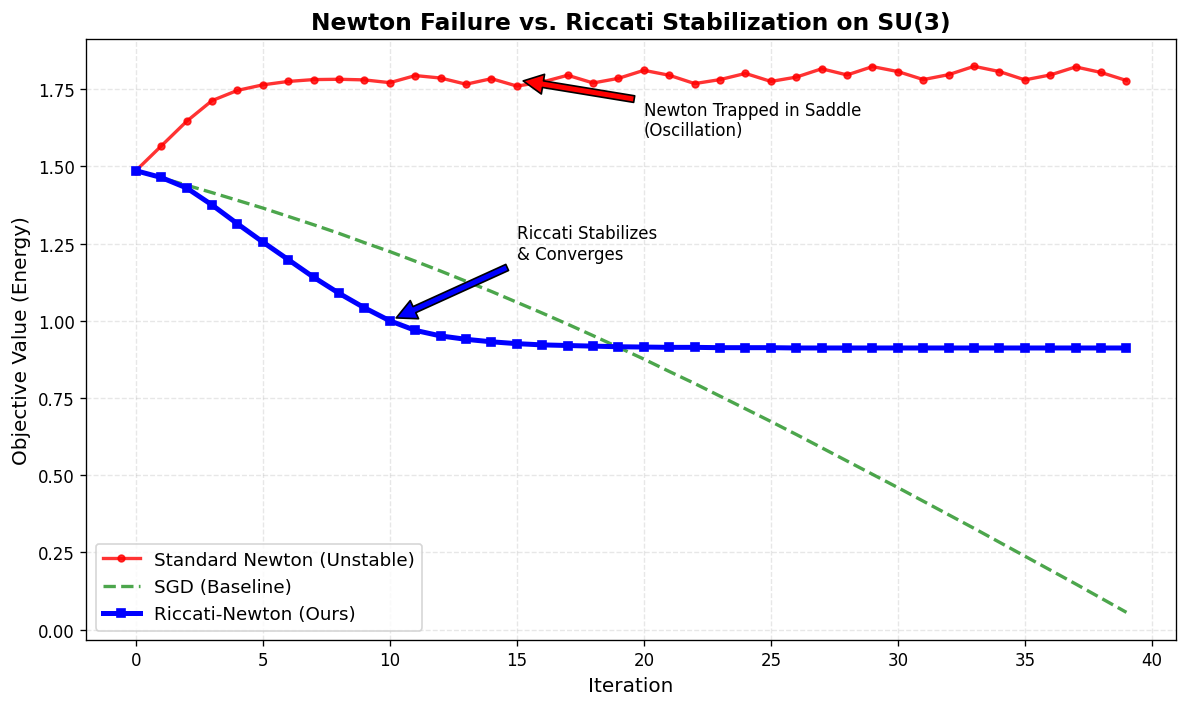

In [ ]:
import matplotlib.pyplot as plt

# Data from your run
fs_sgd = [1.486, 1.463, 1.439, 1.415, 1.390, 1.365, 1.338, 1.311, 1.283, 1.253,
          1.224, 1.193, 1.161, 1.128, 1.095, 1.060, 1.025, 0.989, 0.952, 0.914,
          0.876, 0.836, 0.797, 0.756, 0.715, 0.674, 0.632, 0.589, 0.546, 0.503,
          0.460, 0.416, 0.372, 0.328, 0.283, 0.238, 0.193, 0.148, 0.102, 0.056]

fs_new = [1.486, 1.566, 1.646, 1.713, 1.746, 1.764, 1.775, 1.781, 1.782, 1.780,
          1.771, 1.794, 1.786, 1.766, 1.784, 1.760, 1.773, 1.795, 1.770, 1.785,
          1.811, 1.795, 1.768, 1.781, 1.801, 1.775, 1.789, 1.816, 1.796, 1.823,
          1.807, 1.781, 1.797, 1.824, 1.807, 1.780, 1.796, 1.822, 1.804, 1.778]

fs_rn  = [1.486, 1.464, 1.430, 1.375, 1.314, 1.255, 1.198, 1.141, 1.089, 1.042,
          1.000, 0.969, 0.951, 0.940, 0.932, 0.926, 0.922, 0.920, 0.918, 0.916,
          0.915, 0.914, 0.914, 0.913, 0.913, 0.913, 0.912, 0.912, 0.912, 0.912,
          0.912, 0.912, 0.912, 0.912, 0.912, 0.912, 0.912, 0.912, 0.912, 0.912]

plt.figure(figsize=(10, 6), dpi=120)

# Plot curves
plt.plot(fs_new, 'r-o', label='Standard Newton (Unstable)', linewidth=2, markersize=4, alpha=0.8)
plt.plot(fs_sgd, 'g--', label='SGD (Baseline)', linewidth=2, alpha=0.7)
plt.plot(fs_rn,  'b-s', label='Riccati-Newton (Ours)', linewidth=3, markersize=5)

# Styling
plt.title('Newton Failure vs. Riccati Stabilization on SU(3)', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (Energy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=11)

# Annotations to explain the behavior
plt.annotate('Newton Trapped in Saddle\n(Oscillation)', xy=(15, 1.78), xytext=(20, 1.6),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.annotate('Riccati Stabilizes\n& Converges', xy=(10, 1.0), xytext=(15, 1.2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.tight_layout()
plt.show()